In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.visualize import view
from ase import Atoms
from ase.io import write, read
import io

In [3]:
results_dir = "/home/ilgar/MatterGen_extractLi/examples/li_selective_electrodes/"
train_datasets_dir = "/home/ilgar/MatterGen_extractLi/datasets/"

df_train_old = pd.read_csv(train_datasets_dir + "li_data_20/train.csv")
df_train = pd.read_csv(train_datasets_dir + "li_data_20_host_Na_structures/train.csv")
df_train_diff_add1 = pd.read_csv(train_datasets_dir + "li_data_20_diff_add1/train.csv")
df_train_diff_add2 = pd.read_csv(train_datasets_dir + "li_data_20_diff_add2/train.csv")

df_diff_guide2_small = pd.read_csv(results_dir + "600epochs_LiNadiff/guide2_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_diff_guide4_small = pd.read_csv(results_dir + "600epochs_LiNadiff/guide4_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_diff_guide4 = pd.read_csv(results_dir + "600epochs_LiNadiff/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_diff_add1_guide2 = pd.read_csv(results_dir + "600epochs_LiNadiff_add1/guide2_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_diff_add1_guide4 = pd.read_csv(results_dir + "600epochs_LiNadiff_add1/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_diff_add2_guide2 = pd.read_csv(results_dir + "600epochs_LiNadiff_add2/guide2_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_diff_add2_guide4 = pd.read_csv(results_dir + "600epochs_LiNadiff_add2/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")

dfs = [df_train, df_diff_guide4, df_diff_add1_guide2, df_diff_add1_guide4, df_diff_add2_guide2, df_diff_add2_guide4]
df_names = ["train", "diff_guide4", "diff_add1_guide2", "diff_add1_guide4", "diff_add2_guide2", "diff_add2_guide4"]

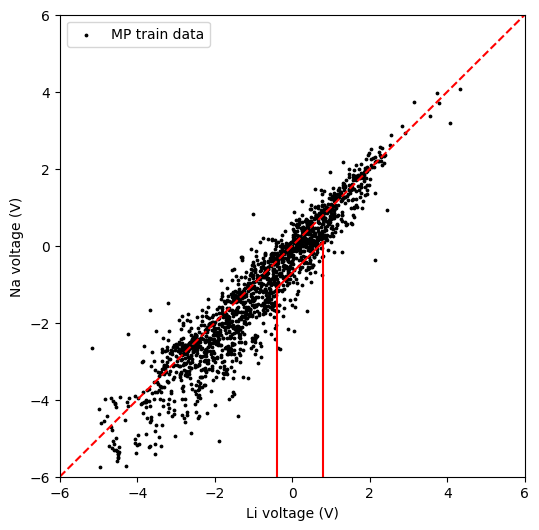

In [3]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

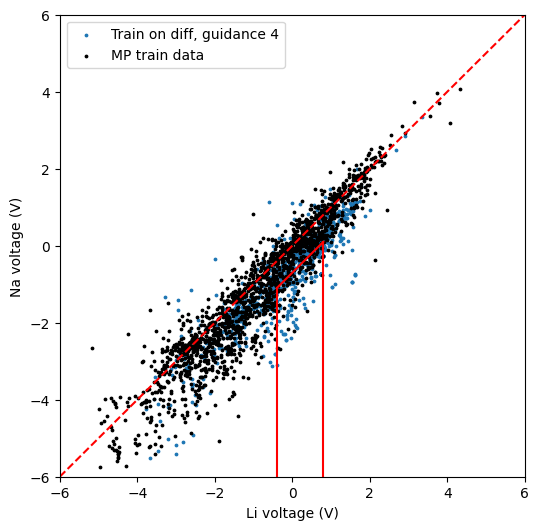

In [14]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_guide4['Li_voltage'],df_diff_guide4['Na_voltage'],s=3,label="Train on diff, guidance 4")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

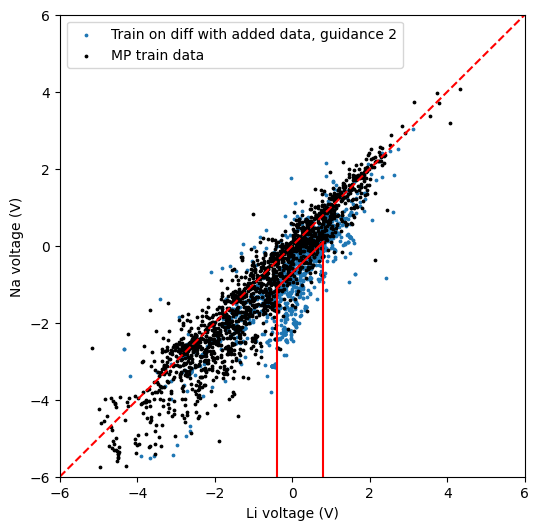

In [15]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_add1_guide2['Li_voltage'],df_diff_add1_guide2['Na_voltage'],s=3,label="Train on diff with added data, guidance 2")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

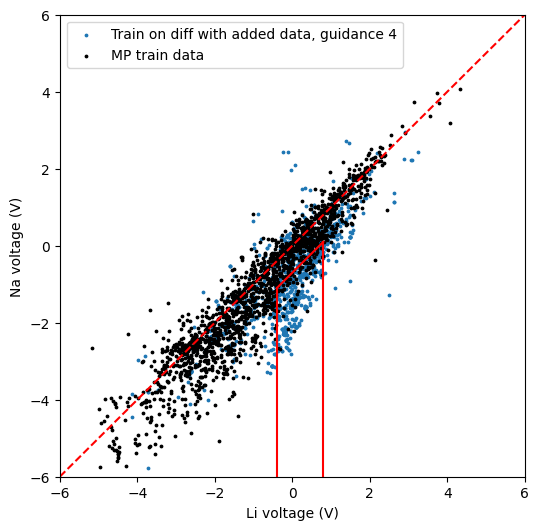

In [16]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_add1_guide4['Li_voltage'],df_diff_add1_guide4['Na_voltage'],s=3,label="Train on diff with added data, guidance 4")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

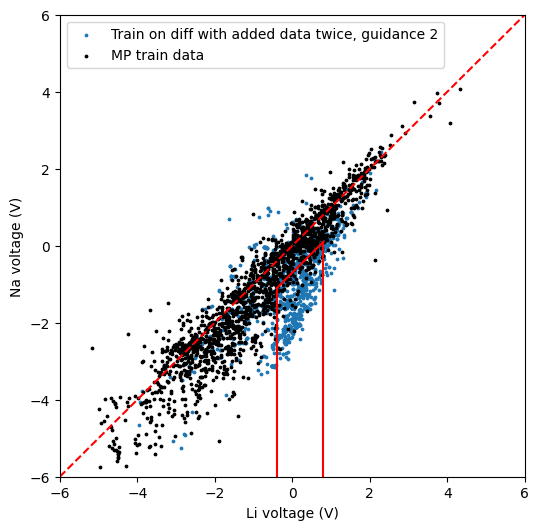

In [17]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_add2_guide2['Li_voltage'],df_diff_add2_guide2['Na_voltage'],s=3,label="Train on diff with added data twice, guidance 2")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

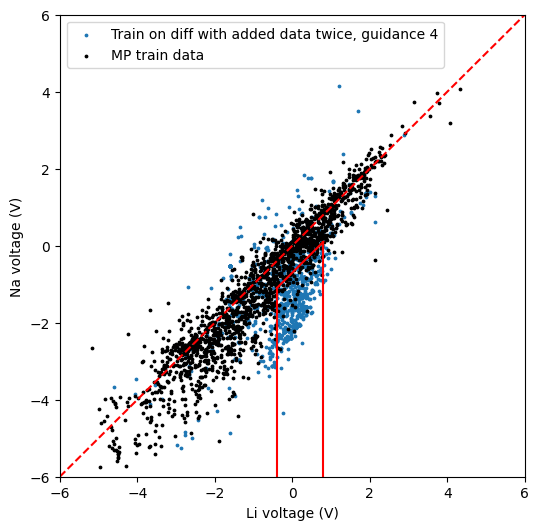

In [18]:
plt.figure(figsize=(6,6))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_add2_guide4['Li_voltage'],df_diff_add2_guide4['Na_voltage'],s=3,label="Train on diff with added data twice, guidance 4")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

Saved scatter_plot.svg


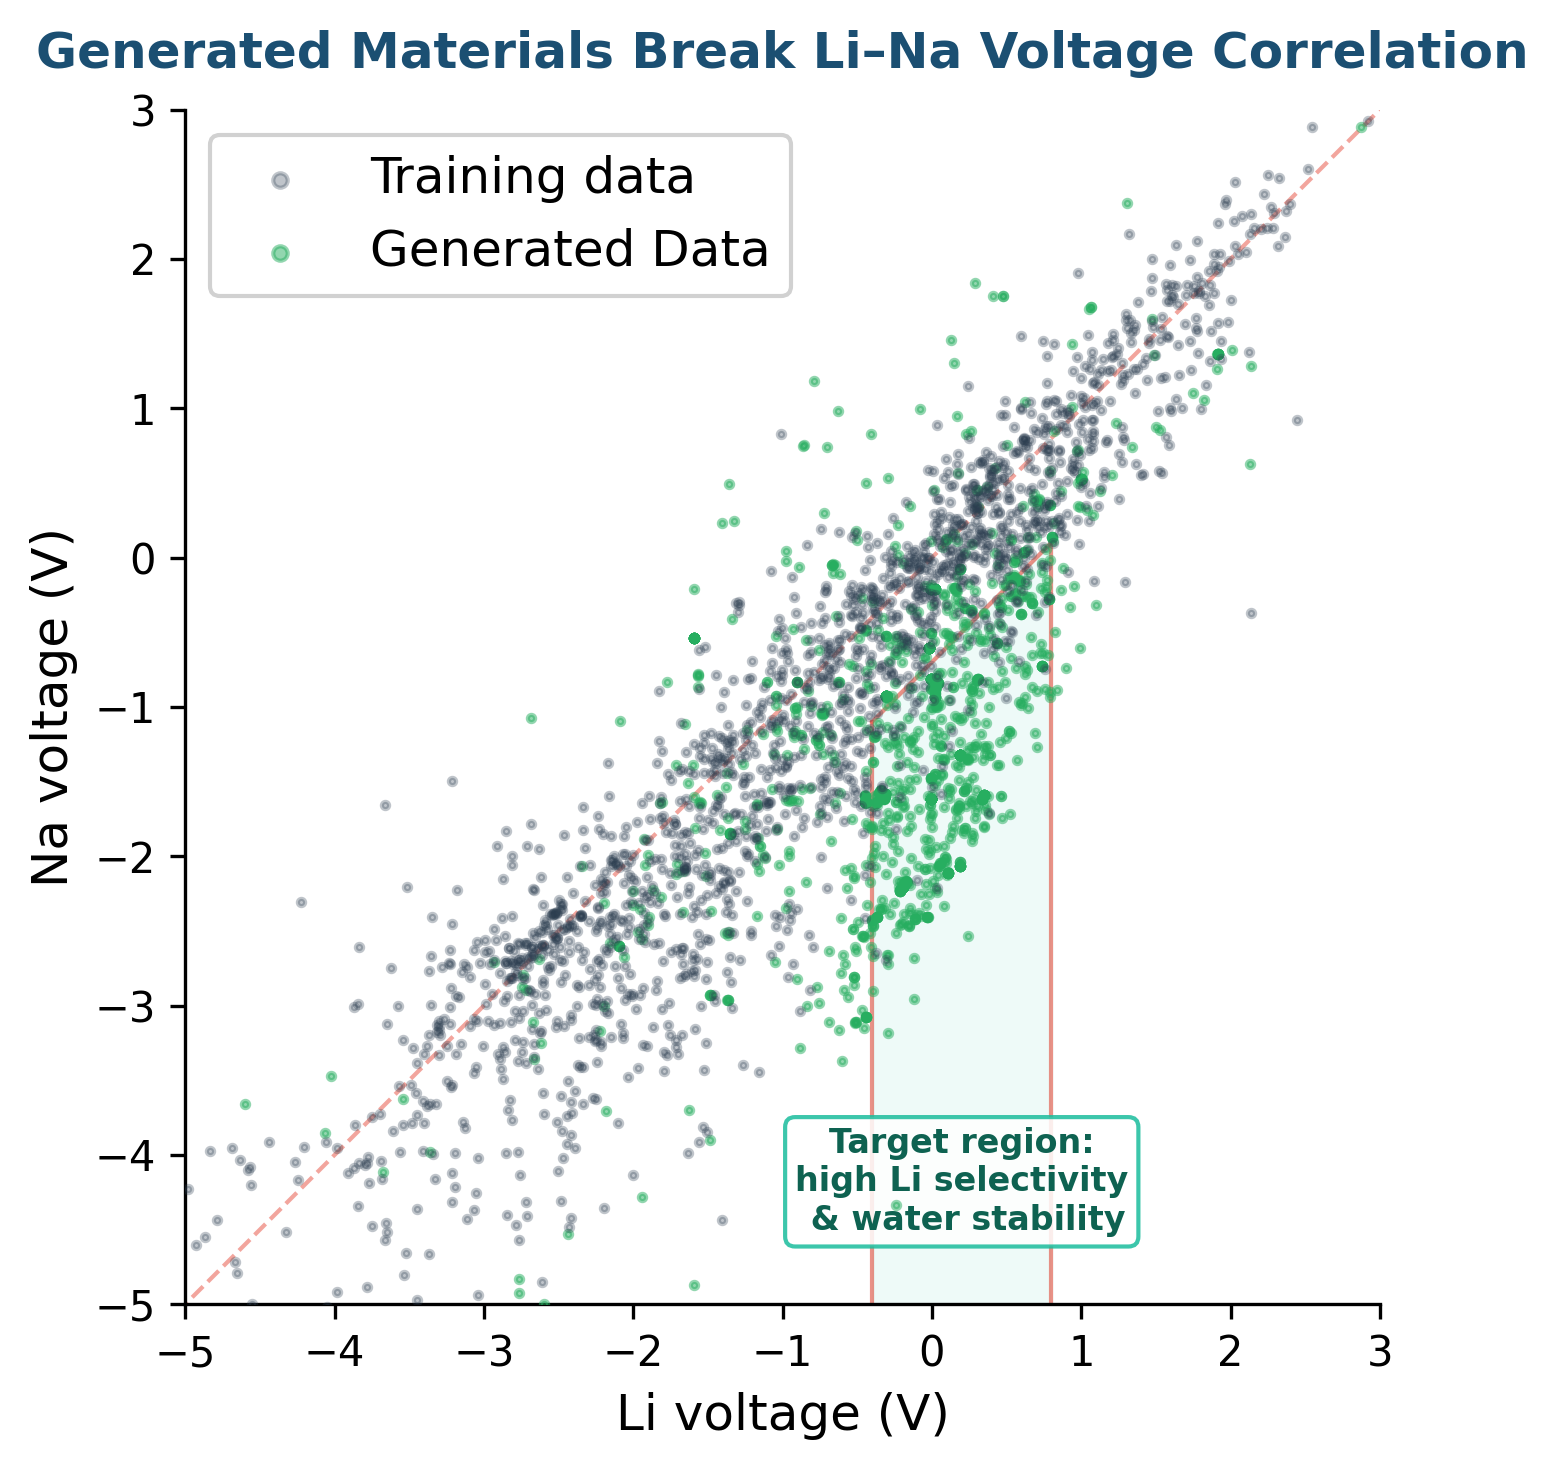

In [23]:
import matplotlib.pyplot as plt

# ---- Your data loading goes here ----
# df_train, df_diff_guide4, df_diff_add1_guide2, etc.

C_PRIMARY = '#1B4F72'
C_RED = '#E74C3C'
C_ACCENT = '#1ABC9C'

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig.patch.set_facecolor('white')

# Training data (plot first so it's behind)
ax.scatter(df_train['Li_voltage'], df_train['Na_voltage'],
           s=3, c='#2C3E50', alpha=0.3, label='Training data', zorder=7, rasterized=True)

# # Generated rounds
# ax.scatter(df_diff_guide4['Li_voltage'], df_diff_guide4['Na_voltage'],
#            s=6, c='#3498DB', alpha=0.5, label='Train on diff, guidance 4', zorder=2, rasterized=True)
# ax.scatter(df_diff_add1_guide2['Li_voltage'], df_diff_add1_guide2['Na_voltage'],
#            s=6, c='#E67E22', alpha=0.5, label='Train on diff + data, guidance 2', zorder=3, rasterized=True)
# ax.scatter(df_diff_add1_guide4['Li_voltage'], df_diff_add1_guide4['Na_voltage'],
#            s=6, c='#8E44AD', alpha=0.5, label='Train on diff + data, guidance 4', zorder=4, rasterized=True)
# ax.scatter(df_diff_add2_guide2['Li_voltage'], df_diff_add2_guide2['Na_voltage'],
#            s=6, c='#E74C3C', alpha=0.5, label='Train on diff + data×2, guidance 2', zorder=5, rasterized=True)
# ax.scatter(df_diff_add2_guide4['Li_voltage'], df_diff_add2_guide4['Na_voltage'],
#            s=3, c='#27AE60', alpha=0.5, label='Train on diff + data×2, guidance 4', zorder=6, rasterized=True)
ax.scatter(df_diff_add2_guide4['Li_voltage'], df_diff_add2_guide4['Na_voltage'],
           s=3, c='#27AE60', alpha=0.5, label='Generated Data', zorder=6, rasterized=True)

# Diagonal y = x
ax.plot([-6, 6], [-6, 6], '--', color=C_RED, linewidth=1, alpha=0.5, zorder=0)

# Water window boundary lines (your original lines)
ax.plot([-0.4, -0.4], [-6, -1.1], c=C_RED, ls='-', lw=1, alpha=0.6)
ax.plot([0.8, 0.8], [-6, 0.1], c=C_RED, ls='-', lw=1, alpha=0.6)
ax.plot([-0.4, 0.8], [-1.1, 0.1], c=C_RED, ls='-', lw=1, alpha=0.6)

# Shade target region
ax.fill([-0.4, 0.8, 0.8, -0.4], [-1.1, 0.1, -6, -6],
        alpha=0.07, color=C_ACCENT, zorder=0)
ax.text(0.2, -4.5, 'Target region:\nhigh Li selectivity\n & water stability',
        fontsize=8, color='#0E6251', ha='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=C_ACCENT))

ax.set_xlim(-5, 3)
ax.set_ylim(-5, 3)
ax.set_xlabel('Li voltage (V)', fontsize=12)
ax.set_ylabel('Na voltage (V)', fontsize=12)
ax.set_title('Generated Materials Break Li–Na Voltage Correlation',
             fontsize=12, fontweight='bold', color=C_PRIMARY, pad=10)
ax.legend(fontsize=12, loc='upper left', framealpha=0.9, markerscale=2)
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('scatter_plot.svg', bbox_inches='tight', facecolor='white')
print("Saved scatter_plot.svg")


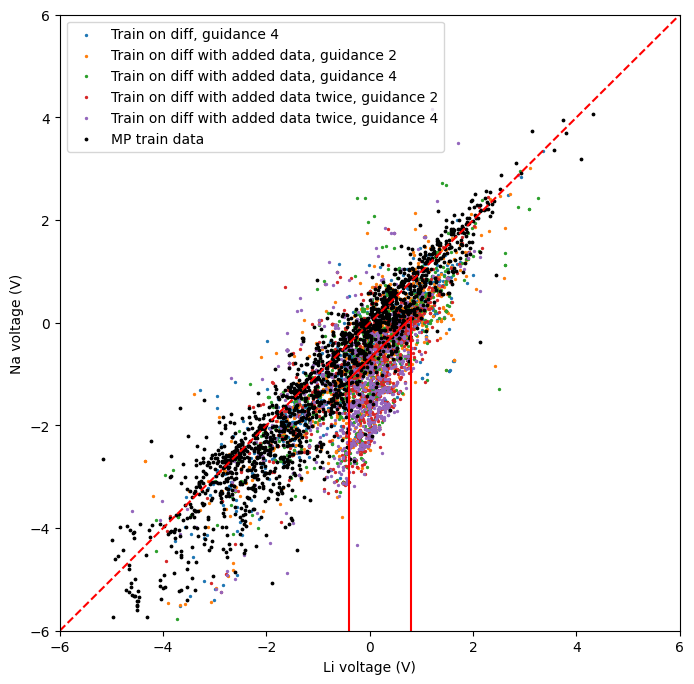

In [23]:
plt.figure(figsize=(8,8))
plt.plot([-6,6],[-6,6],c='r',ls='--')
plt.plot([-0.4,-0.4],[-6,-1.1],c='r',ls='-')
plt.plot([0.8,0.8],[-6,0.1],c='r',ls='-')
plt.plot([-0.4,0.8],[-1.1,0.1],c='r',ls='-')
plt.scatter(df_diff_guide4['Li_voltage'],df_diff_guide4['Na_voltage'],s=2,label="Train on diff, guidance 4")
plt.scatter(df_diff_add1_guide2['Li_voltage'],df_diff_add1_guide2['Na_voltage'],s=2,label="Train on diff with added data, guidance 2")
plt.scatter(df_diff_add1_guide4['Li_voltage'],df_diff_add1_guide4['Na_voltage'],s=2,label="Train on diff with added data, guidance 4")
plt.scatter(df_diff_add2_guide2['Li_voltage'],df_diff_add2_guide2['Na_voltage'],s=2,label="Train on diff with added data twice, guidance 2")
plt.scatter(df_diff_add2_guide4['Li_voltage'],df_diff_add2_guide4['Na_voltage'],s=2,label="Train on diff with added data twice, guidance 4")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

In [5]:
for df in dfs[1:]:
    df.rename(columns={"filename": "material_id"}, inplace=True)
    df.rename(columns={"Li_structure": "cif"}, inplace=True)
    drop_columns = [col for col in df.columns if col not in dfs[0].columns]
    df.drop(columns=drop_columns, inplace=True)
    df.dropna(inplace=True)
for df in dfs:
    df.drop(df[(df["Li_voltage"] < -0.4) | (df["Li_voltage"] > 0.8)].index, inplace=True)
    df.drop(df[(df["Li_voltage"] - df["Na_voltage"] < 0.7)].index, inplace=True)

# merge dataframe in dfs by rows and add a column "dataset" to indicate the source of each row 
# also add an ID column that indicates the index of the row in the original dataframe
merged_df = pd.DataFrame()
for i, df in enumerate(dfs):
    df["dataset"] = df_names[i]
    df["ID"] = df.index
    merged_df = pd.concat([merged_df, df], ignore_index=True)

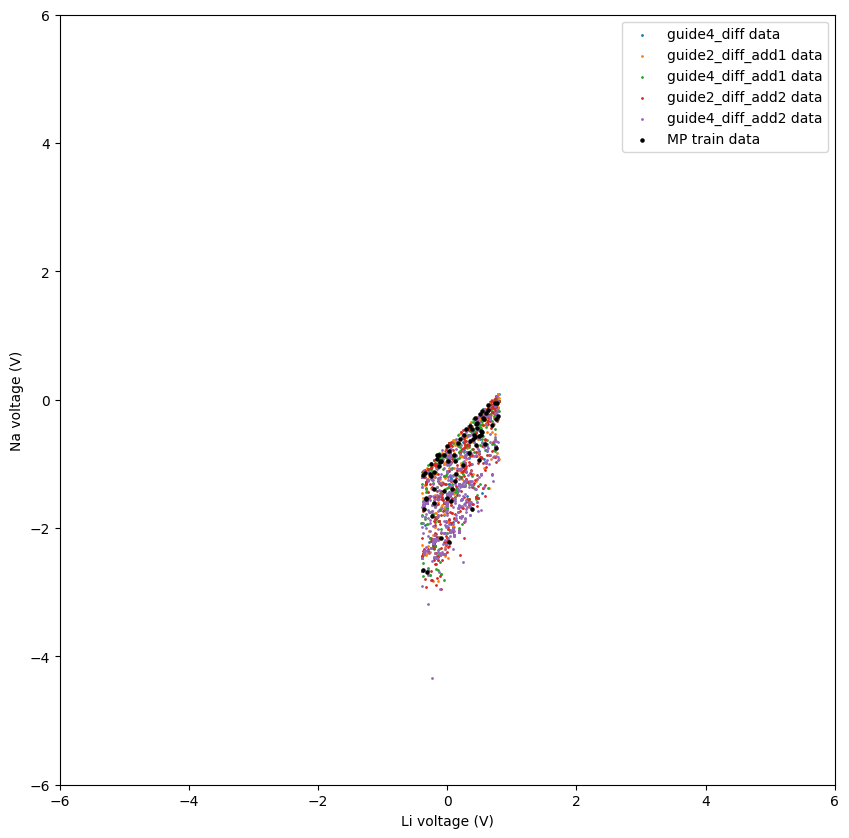

In [6]:
plt.figure(figsize=(10,10))
plt.scatter(df_diff_guide4['Li_voltage'],df_diff_guide4['Na_voltage'],s=1,label="guide4_diff data")
plt.scatter(df_diff_add1_guide2['Li_voltage'],df_diff_add1_guide2['Na_voltage'],s=1,label="guide2_diff_add1 data")
plt.scatter(df_diff_add1_guide4['Li_voltage'],df_diff_add1_guide4['Na_voltage'],s=1,label="guide4_diff_add1 data")
plt.scatter(df_diff_add2_guide2['Li_voltage'],df_diff_add2_guide2['Na_voltage'],s=1,label="guide2_diff_add2 data")
plt.scatter(df_diff_add2_guide4['Li_voltage'],df_diff_add2_guide4['Na_voltage'],s=1,label="guide4_diff_add2 data")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=5,label="MP train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

In [7]:
atoms_list = []
for index, row in merged_df.iterrows():
    cif = row["cif"]
    f = io.StringIO(cif)
    atoms = read(f, format='cif')
    for col in merged_df.columns:
        if col != "cif":
            atoms.info[col] = row[col]
    atoms_list.append(atoms)
write("merged_data.traj", atoms_list)

In [8]:
merged_df.to_csv("merged_data.csv", index=False)

In [42]:
view(atoms_list[-1], viewer='x3d')